## 0. Import and Definitions

In [18]:
import os
import copy
from sklearn.metrics import roc_curve, auc

import anndata as ad
from mudata import MuData

import numpy as np
import matplotlib.pyplot as plt

from src.analysis.mmd import ctrl_mmd_dists, mmd_dists, plot_mmd_dists
from src.analysis.analysis_utils import (
    Analyzer,
)
from src.analysis.logistic_regression import (
    train_classifier,
    generate_counterfactuals,
    init_classifier,
    evaluate_training_error,
)
from src.analysis.cluster_analysis import (
    plot_latent_means_umap,
)

from src.model.data_utils import (
    load_data,
    get_condition_shapes,
    prepare_train_test_data,
    build_metacells,
)
from src.model.training import train_model
from src.model.build_model import get_model, remap_keys, init_config
from src.model.config import INNConfig
from src.analysis.cf_expressions import plot_mean_expression_comparison

import warnings
import socket
import torch

assert "login" not in socket.gethostname()

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
adata = None
analyzer = None

## 1. Load Data

In [3]:
USE_METACELLS = False
DONOR = ["Donor1"]

In [4]:
dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 4,
    "batch_size": 512,
}

In [5]:
dataset_args["sigma_noise"] = 0.1
dataset_args["lam_MTC"] = 0.3
dataset_args["use_counts"] = False
dataset_args["batch_size"] = 1024
prefix = "4_8_"

In [6]:
if not USE_METACELLS:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=["CD4 Memory"],
    )
else:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=None,
        donors=DONOR,
    )
    print(adata.X.shape)
    adata = build_metacells(adata, group_keys=["cell_type", f"{labels_key}"])

mdata = MuData({"rna": adata})
dataset_args["top_genes"] = min(adata.shape[1], dataset_args["top_genes"])

## 2. Model

### 2.1 Setup

In [7]:
conditions = [f"{labels_key}"]
condition_shapes = None
condition_type = None
if conditions is not None:
    condition_shapes = get_condition_shapes(adata, conditions)
    condition_type = "mixture"
    trainable_means = True
    trainable_simga = True
print("Condition shapes:", condition_shapes)

supervise_latent_meaning = "partition"
lam_supervise = 0.01

Condition shapes: [11]


In [8]:
test_size = 0.0

dataset, dataloader, test_dataset, test_dataloader = prepare_train_test_data(
    adata,
    dataset_args["batch_size"],
    device,
    dtype,
    counts=dataset_args["use_counts"],
    label_key=conditions,
    test_size=test_size,
)
D_dim = dataset.X.shape[1]
N_dim = D_dim

In [9]:
dataset_name = dataset_args["dataset_name"]
top_genes = min(dataset_args["top_genes"], D_dim)
sigma_noise = dataset_args["sigma_noise"]
lam_MTC = dataset_args["lam_MTC"]

model_path = os.path.join(
    "/g/stegle/jhoefer/models/EOFlow", dataset_name, "top_" + str(top_genes)
)
model_name = prefix + "MTC_" + str(lam_MTC) + "_sigma_" + str(sigma_noise) + "_model.pt"

output_dir_path = os.path.join(
    "/home/jhoefer/sandbox/results", dataset_name, "top_" + str(top_genes)
)
output_dir_name = prefix + "MTC_" + str(lam_MTC) + "_sigma_" + str(sigma_noise)

if dataset_args["use_counts"]:
    model_path += "_counts"
    output_dir_path += "_counts"

model_path += "_best"
output_dir_path += "_best"
print(f"Model path: {model_path}")
print(f"Model name: {model_name}")

plot_dir = os.path.join(output_dir_path, "plots", output_dir_name)
log_dir = os.path.join(output_dir_path, "logs", output_dir_name)
csv_dir = os.path.join(output_dir_path, "csv", output_dir_name)
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)

checkpoint_path = os.path.join(model_path, model_name)

Model path: /g/stegle/jhoefer/models/EOFlow/parse/top_1779_best
Model name: 4_8_MTC_0.3_sigma_0.1_model.pt


In [10]:
kwargs_data = {
    "device": device,
    "dtype": dtype,
    "N_dim": N_dim,
    "D_dim": D_dim,
    "dataset": dataset,
    "train_dataloader": dataloader,
    "test_dataloader": test_dataloader,
    "data_mean": dataset.X.mean(dim=0),
    "data_std": torch.ones(D_dim),
    "sigma_noise": sigma_noise,
    "sigma_inflate": sigma_noise,
}

kwargs_loss = {
    "use_NLL": True,
    "use_MER": True,
    "mode_MER": "unbiased",  #'full', #'unbiased'
    "lam_MTC": lam_MTC,
    "lam_ME_i": list(np.zeros(D_dim)),
    # 'use_align': False,
    # 'dims_align': D_dim - 1,
    # 'lam_align': 1, #0.1,
    # 'lam_disent': 0, #0.1,
    "use_rec": False,
    "dims_rec": D_dim - 1,
    "lam_rec": 100,  #
    "sigma_noise": sigma_noise,
}

metrics_loss = {
    "epoch": [],
    "loss": [],
    "z2": [],
    "NLL": [],
    "MTC": [],
    "H_i": [],
    "H_core": [],
    "H_detail": [],
    "MI_core_detail": [],
    "L2_rec": [],
}
val_metrics_loss = metrics_loss.copy()

In [11]:
model_config = INNConfig(
    N_dim=N_dim,
    N_blocks=8,
    condition_shapes=condition_shapes,
    pre_normalize=False,
    normalize=True,
    warmup_steps=2 * len(dataloader),
    condition_type=condition_type,
    trainable_means=trainable_means,
    n_clusters=len(dataset.cats[0].categories),
    lr_means=5e-3,
    supervise_latent_meaning=supervise_latent_meaning,
    ctrl_idx=dataset.cats[0].categories.tolist().index(control_label),
    lam_supervise=lam_supervise,
    trainable_sigma=trainable_simga,
    latent_per_condition=8,
)

flow, optimizer = get_model(model_config)

In [12]:
CONTINUE_TRAINING = False
NUM_EPOCHS = 1
# NUM_EPOCHS = int(NUM_EPOCHS * N_dim / dataset_args["batch_size"])
start_epoch = 0
log_path = None

### 2.2 Train or Load 

In [13]:
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    metrics_loss = checkpoint["metrics_loss"]

    if "val_metrics_loss" in checkpoint:
        val_metrics_loss = checkpoint["val_metrics_loss"]

    log_path = checkpoint["log_path"]
    start_epoch = checkpoint["epoch"] + 1
    model_config = checkpoint["model_config"]

    model_config = init_config(model_config)

    print(f"Checkpoint found at epoch {checkpoint['epoch']}.")

    model, optimizer = get_model(model_config)

    model = model.to(device)
    saved_state = checkpoint["model_state_dict"]

    ## TODO: Remove fix
    # model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    model = remap_keys(model, saved_state)
    
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    
else:
    print("No checkpoint found, starting training from scratch.")
    model, optimizer = get_model(model_config)
    model = model.to(device)

if CONTINUE_TRAINING:
    print(f"Starting training from epoch {start_epoch}...")

    model, optimizer, metrics_loss, val_metrics_loss, log_path = train_model(
        model,
        optimizer,
        metrics_loss,
        kwargs_data,
        kwargs_loss,
        save_model_path=checkpoint_path,
        model_config=model_config,
        val_metrics_loss=val_metrics_loss,
        num_epochs=NUM_EPOCHS,
        start_epoch=start_epoch,
        print_info=True,
        log_dir=log_dir,
        continue_log_path=log_path,
        conditions=conditions,
    )

Checkpoint found at epoch 1551.
Loaded successfully. Missing/fresh keys: []


In [14]:
analyzer = Analyzer(
    adata,
    model,
    kwargs_data,
    labels_key,
    control_label,
    plot_dir,
    csv_dir,
    checkpoint_path,
    metrics_loss,
    conditions=conditions,
    condition_type=model_config.condition_type,
    val_metrics_loss=val_metrics_loss,
)

## 3. Evaluation

### 3.1 Clusters

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 1779 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


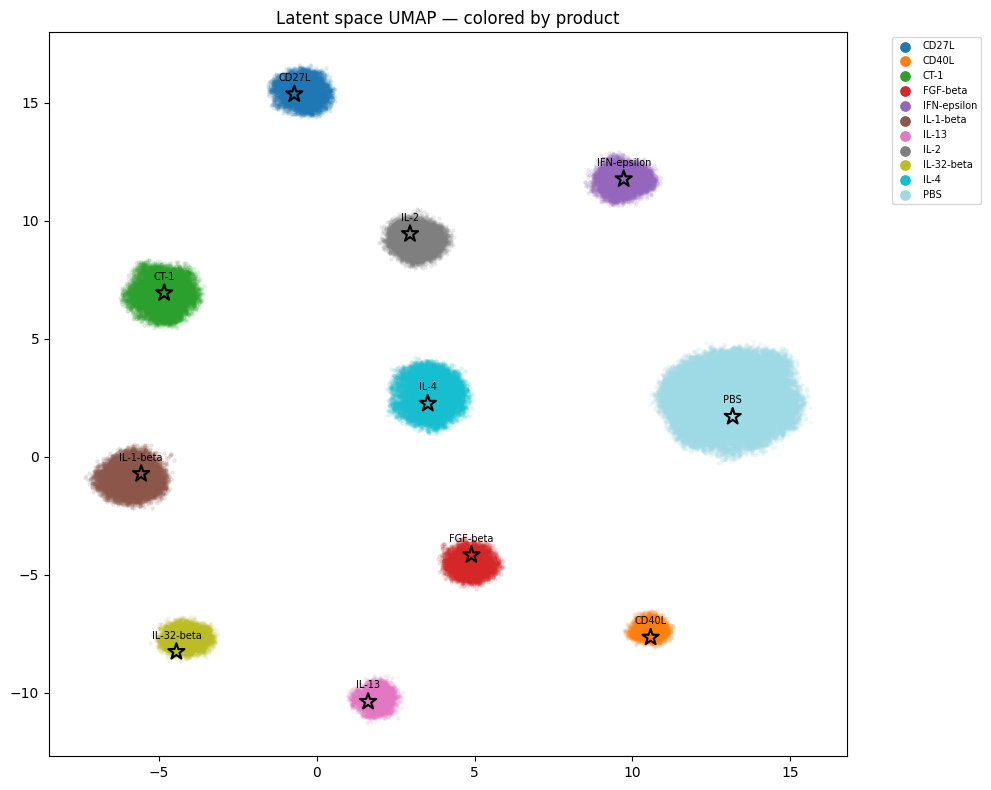

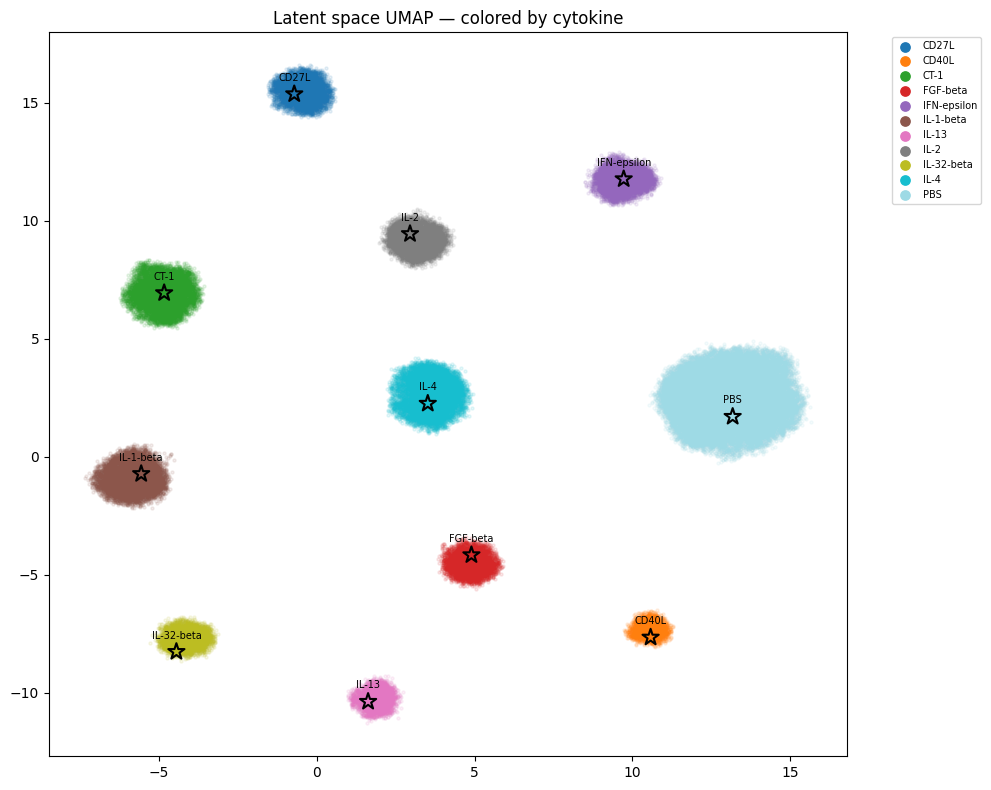

In [15]:
plot_latent_means_umap(analyzer)

### 3.2 Counterfactuals

In [19]:
key = "PBS"

In [20]:
x_cfs, z_cfs, all_source_labels, key_mean = generate_counterfactuals(analyzer, key=key)

adata_real = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
adata_real.obs["origin"] = "original"

adata_cf = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] != key].copy()
adata_cf.X = x_cfs.numpy()
adata_cf.obs["origin"] = "cfs"
adata_cf.obs["source"] = all_source_labels  # keep track of where each cf came from

adata_combined = ad.concat([adata_real, adata_cf])

analyzer_cfs = copy.deepcopy(analyzer)
analyzer_cfs.adata = adata_combined

num_original = adata_real.shape[0]
num_cfs = adata_cf.shape[0]

weights = torch.tensor(
    [1.0 / num_cfs, 1.0 / num_original],
    dtype=torch.float32,
    device=device,
)

weights = weights / weights.sum() * len(weights)

In [22]:
cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, cfs_train_dataset, cfs_adata_train, cfs_num_classes = init_classifier(analyzer_cfs, key, latent=False, hidden_dim = None, labels_key="origin")

cfs_accuracies, cfs_train_loss, cfs_val_loss, cfs_class_accuracies = train_classifier(
    cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, weights, analyzer_cfs.device, num_epochs=10
)

100%|████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.35it/s]

Best Validation Accuracy: 0.9677


In [23]:
evaluate_training_error(analyzer, cfs_adata_train, "origin", cfs_num_classes, cfs_class_accuracies)

,Class,Accuracy
0,cfs,0.970083
1,original,0.963152


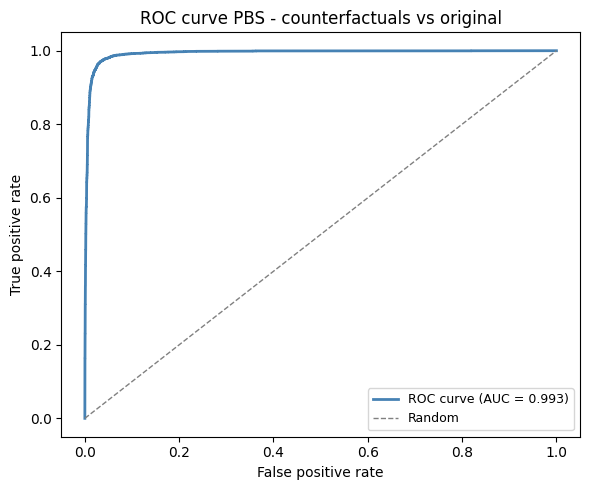

AUC: 0.993


In [24]:
cats = cfs_train_dataset.cats[0].categories.tolist()
target_idx = cats.index("original")

cfs_classifier.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in cfs_test_dataloader:
        x = x.to(analyzer.device)
        logits = cfs_classifier(x)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y[0].argmax(dim=1).cpu().numpy())  # one-hot to int

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# for binary classifier: use probability of positive class
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, target_idx])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curve {key} - counterfactuals vs original")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"roc_curve_{key}.png"), dpi=300)
plt.show()

print(f"AUC: {roc_auc:.3f}")

### 3.3 MMD

In [25]:
ctrl_mmd = ctrl_mmd_dists(analyzer, key=key)
print(f"Control MMD (random split): {ctrl_mmd:.4f}")
global_mmd, mmd_per_group = mmd_dists(analyzer, key=key, sigma=1.0)
print(f"Global MMD for {key}: {global_mmd}")

Control MMD (random split): 0.0001


100%|████████████████████████████████████████████████████████████| 11/11 [01:55<00:00, 10.47s/it]

Global MMD for PBS: 0.0009541511535644531


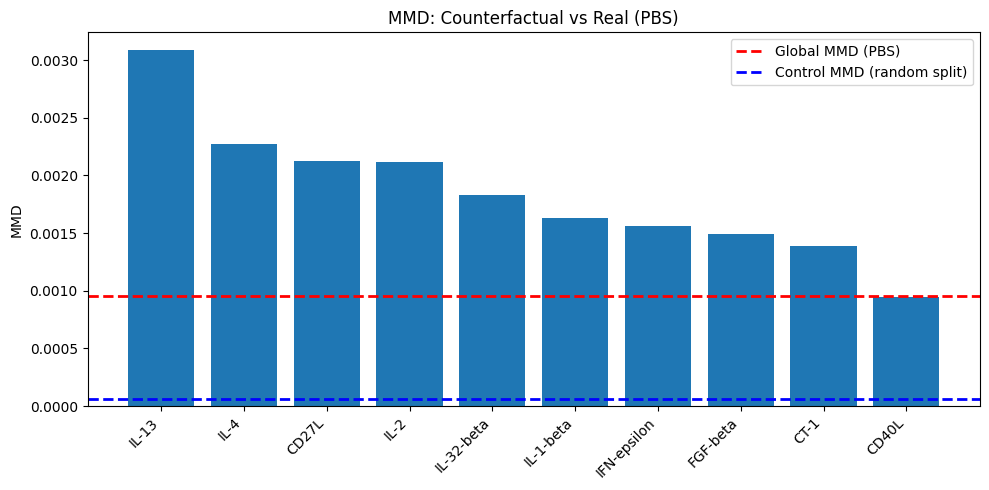

In [27]:
plot_mmd_dists(analyzer, ctrl_mmd, global_mmd, mmd_per_group, key=key)

### 3.4 Mean Expressions

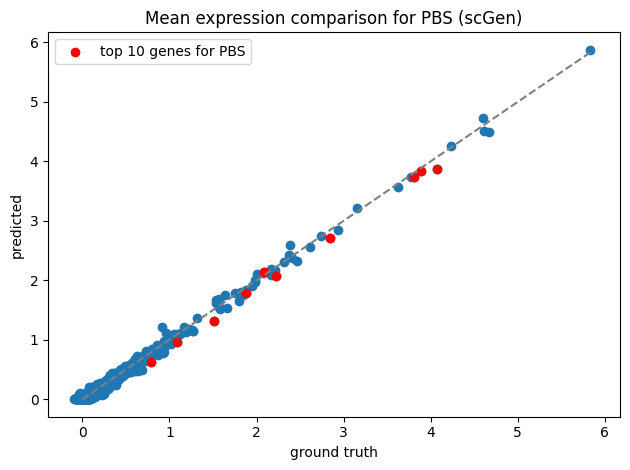

In [ ]:
plot_mean_expression_comparison(analyzer, key=key, top_n=10, method="EOFlow")